# 4. Metodología de Segmentación

## 4.1 Selección del Número de Clusters


In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
X = np.load('../models/X.npy')
df = pd.read_pickle('../data/processed/df_processed.pkl')
scaler = pickle.load(open('../models/scaler.pkl', 'rb'))
print(f"Matriz de clustering: {X.shape}")


Matriz de clustering: (9996, 32)


In [2]:
# Barrido K=2 a 8 con 4 métricas
results = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=50, random_state=42, max_iter=300)
    labels = km.fit_predict(X)
    results.append({
        'K': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
    })

results_df = pd.DataFrame(results).set_index('K')
display(results_df.round(4))


,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
K,,,,
2,70225.9886,0.2736,4747.9955,1.3818
3,62826.2999,0.2464,3241.8281,1.5743
4,56469.9637,0.1731,2779.1542,1.6947
5,51601.9383,0.1743,2516.4055,1.6442
6,48015.8121,0.1624,2312.4818,1.6886
7,45110.2898,0.1699,2158.2153,1.5776
8,42800.6602,0.1760,2026.5253,1.5632


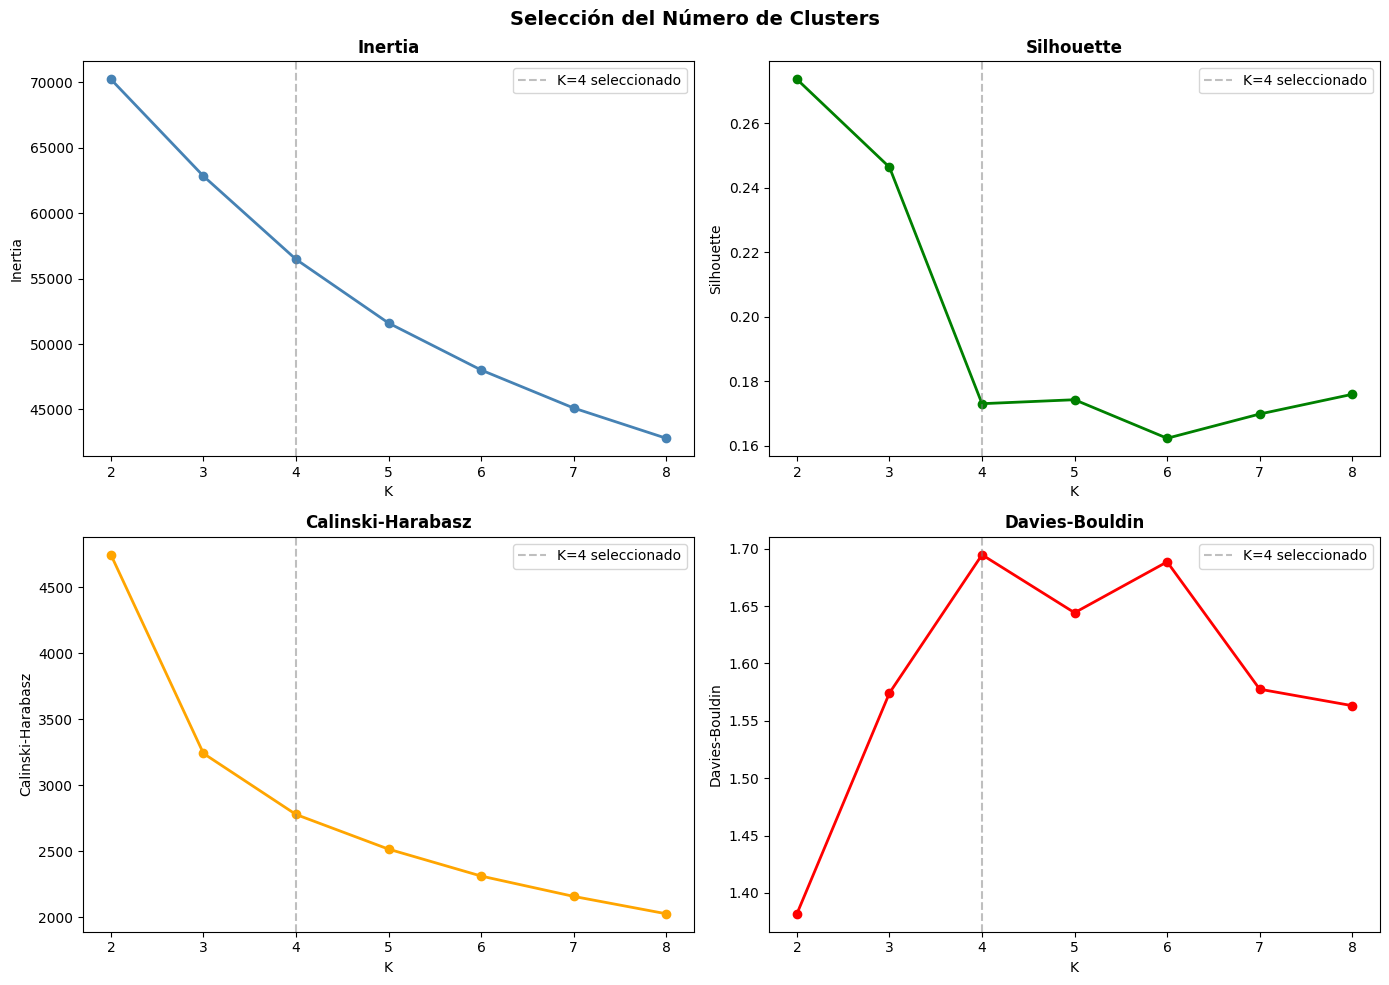

K=3 tiene métricas levemente mejores, pero K=4 separa el segmento mobile.
Decisión: K=4 por ACCIONABILIDAD de negocio.


In [3]:
# Visualización de las 4 métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Inertia', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
colors = ['steelblue', 'green', 'orange', 'red']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[i//2, i%2]
    ax.plot(results_df.index, results_df[metric], 'o-', color=color, linewidth=2)
    ax.axvline(x=4, color='gray', linestyle='--', alpha=0.5, label='K=4 seleccionado')
    ax.set_xlabel('K'); ax.set_ylabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.legend()
plt.suptitle('Selección del Número de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

print("K=3 tiene métricas levemente mejores, pero K=4 separa el segmento mobile.")
print("Decisión: K=4 por ACCIONABILIDAD de negocio.")


## 4.2 Benchmark de Algoritmos


In [4]:
# Benchmark de algoritmos
km4 = KMeans(n_clusters=4, n_init=50, random_state=42).fit(X)
ward4 = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X)
gmm4 = GaussianMixture(n_components=4, random_state=42).fit(X)

algos = {
    'KMeans': km4.labels_,
    'Ward': ward4.labels_,
    'GMM': gmm4.predict(X),
}

benchmark = []
for name, labels in algos.items():
    benchmark.append({
        'Algoritmo': name,
        'Silhouette': silhouette_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Tamaños': str(np.bincount(labels)),
    })

display(pd.DataFrame(benchmark).set_index('Algoritmo').round(4))

# Concordancia KMeans ↔ Ward
ari = adjusted_rand_score(km4.labels_, ward4.labels_)
print(f"\nARI KMeans vs Ward: {ari:.4f}")
print("Alta concordancia → robustez de la estructura encontrada.")
print("\nJustificación KMeans: viabilidad de despliegue (centroides), concordancia con Ward.")


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Tamaños
Algoritmo,,,,
KMeans,0.1731,2779.1542,1.6947,[3382 2448 1014 3152]
Ward,0.1322,2269.6182,1.9317,[3336 3196 2680 784]
GMM,-0.0143,326.0806,2.8115,[7974 756 838 428]



ARI KMeans vs Ward: 0.4621
Alta concordancia → robustez de la estructura encontrada.

Justificación KMeans: viabilidad de despliegue (centroides), concordancia con Ward.


## 4.3 Modelo Final: KMeans K=4


In [5]:
# Modelo final
model = KMeans(n_clusters=4, n_init=50, random_state=42, max_iter=300)
labels = model.fit_predict(X)
df['cluster'] = labels

# Nombres interpretativos
cluster_names = {0: 'Desktop Engaged', 1: 'Desktop Frecuente',
                 2: 'Weekend Warriors', 3: 'Mobile Users'}
df['cluster_name'] = df['cluster'].map(cluster_names)

print("=== DISTRIBUCIÓN DE CLUSTERS ===")
for cid in sorted(df['cluster'].unique()):
    n = (df['cluster'] == cid).sum()
    pct = n / len(df) * 100
    print(f"  C{cid} {cluster_names[cid]}: {n:,} visitantes ({pct:.1f}%)")

# Guardar modelo
pickle.dump(model, open('../models/kmeans_k4.pkl', 'wb'))
print("\nModelo guardado: models/kmeans_k4.pkl")


=== DISTRIBUCIÓN DE CLUSTERS ===
  C0 Desktop Engaged: 3,382 visitantes (33.8%)
  C1 Desktop Frecuente: 2,448 visitantes (24.5%)
  C2 Weekend Warriors: 1,014 visitantes (10.1%)
  C3 Mobile Users: 3,152 visitantes (31.5%)

Modelo guardado: models/kmeans_k4.pkl


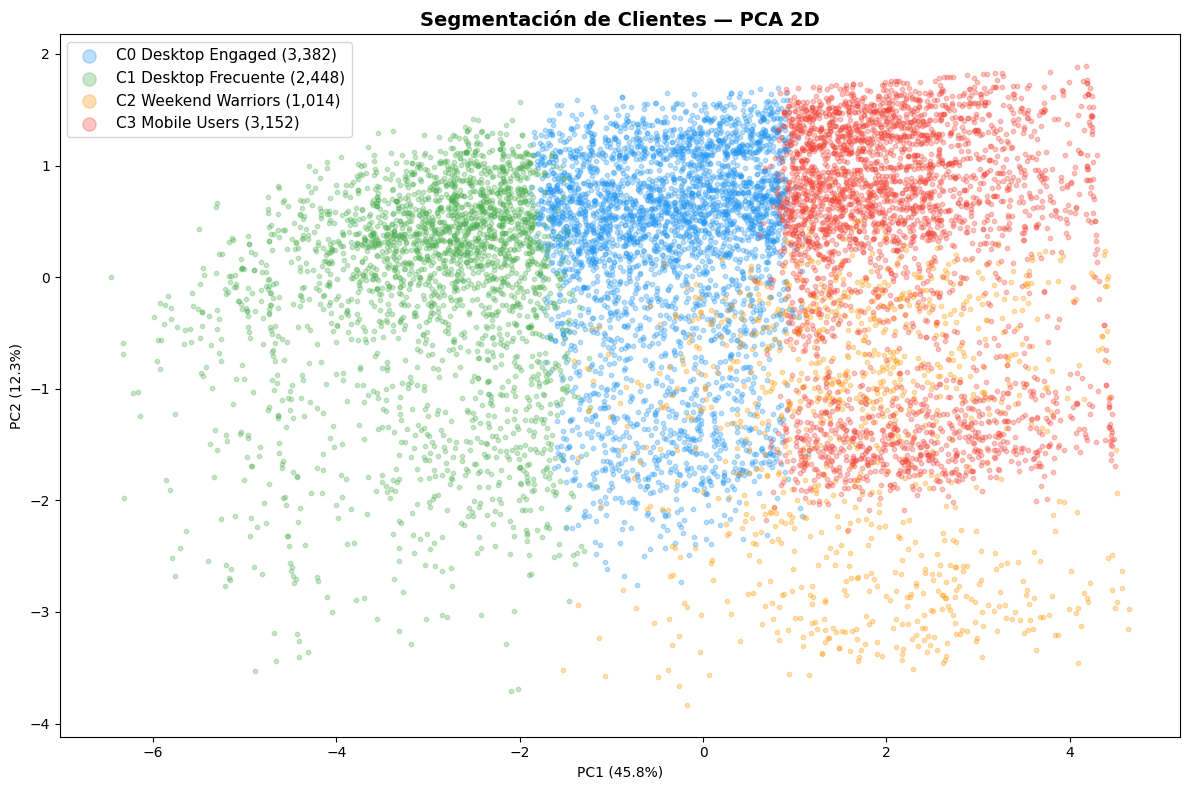

In [6]:
# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cid], alpha=0.3, s=10,
              label=f'C{cid} {cluster_names[cid]} ({mask.sum():,})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=3, fontsize=11)
ax.set_title('Segmentación de Clientes — PCA 2D', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/02_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


# 5. Validación de Robustez

## 5.1 Concepto

En clustering no hay etiquetas verdaderas. No aplican accuracy, AUC ni train/test split clásico. La pregunta correcta: **¿son los clusters estables y reproducibles?**


In [7]:
# 5.2 Estabilidad multi-semilla
print("=== ESTABILIDAD MULTI-SEMILLA ===")
seeds = [0, 7, 13, 42, 99, 123]
all_labels = []
for s in seeds:
    km = KMeans(n_clusters=4, n_init=50, random_state=s).fit(X)
    all_labels.append(km.labels_)

aris = []
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        aris.append(ari)
print(f"ARI entre {len(seeds)} semillas: {np.mean(aris):.4f} ± {np.std(aris):.4f}")
print(f"Min ARI: {min(aris):.4f}")


=== ESTABILIDAD MULTI-SEMILLA ===


ARI entre 6 semillas: 0.9971 ± 0.0014
Min ARI: 0.9943


In [8]:
# 5.3 Bootstrap stability (Hennig 2007)
print("=== BOOTSTRAP STABILITY ===")
n_boot = 30
ref_labels = KMeans(n_clusters=4, n_init=50, random_state=42).fit_predict(X)
boot_aris = []
for i in range(n_boot):
    idx = np.random.RandomState(i).choice(len(X), size=int(0.8*len(X)), replace=True)
    X_boot = X[idx]
    km_boot = KMeans(n_clusters=4, n_init=20, random_state=i).fit(X_boot)
    # Predecir todos los puntos con el modelo bootstrap
    labels_boot = km_boot.predict(X)
    ari = adjusted_rand_score(ref_labels, labels_boot)
    boot_aris.append(ari)

print(f"ARI medio: {np.mean(boot_aris):.4f}")
print(f"ARI mediana: {np.median(boot_aris):.4f}")
print(f"ARI min: {min(boot_aris):.4f}")
print(f"ARI std: {np.std(boot_aris):.4f}")


=== BOOTSTRAP STABILITY ===


ARI medio: 0.9319
ARI mediana: 0.9498
ARI min: 0.8431
ARI std: 0.0439


In [9]:
# 5.4 Hold-out 80/20
from sklearn.model_selection import KFold
print("=== HOLD-OUT 80/20 (10 folds) ===")
sil_train, sil_test = [], []
kf = KFold(n_splits=10, shuffle=True, random_state=42)
for train_idx, test_idx in kf.split(X):
    km = KMeans(n_clusters=4, n_init=20, random_state=42).fit(X[train_idx])
    sil_train.append(silhouette_score(X[train_idx], km.labels_))
    sil_test.append(silhouette_score(X[test_idx], km.predict(X[test_idx])))

print(f"Silhouette train: {np.mean(sil_train):.4f} ± {np.std(sil_train):.4f}")
print(f"Silhouette test:  {np.mean(sil_test):.4f} ± {np.std(sil_test):.4f}")
print(f"Gap: {abs(np.mean(sil_train) - np.mean(sil_test)):.4f}")
print("Gap ≈ 0 → No hay overfitting.")


=== HOLD-OUT 80/20 (10 folds) ===


Silhouette train: 0.1734 ± 0.0009
Silhouette test:  0.1726 ± 0.0044
Gap: 0.0008
Gap ≈ 0 → No hay overfitting.


In [10]:
# 5.5 Robustez al ruido
print("=== ROBUSTEZ AL RUIDO GAUSSIANO (σ=0.1) ===")
np.random.seed(42)
X_noisy = X + np.random.normal(0, 0.1, X.shape)
labels_noisy = KMeans(n_clusters=4, n_init=50, random_state=42).fit_predict(X_noisy)
ari_noise = adjusted_rand_score(ref_labels, labels_noisy)
changed = (ref_labels != labels_noisy).sum()
print(f"ARI con ruido: {ari_noise:.4f}")
print(f"Visitantes que cambian de cluster: {changed} ({changed/len(X)*100:.1f}%)")


=== ROBUSTEZ AL RUIDO GAUSSIANO (σ=0.1) ===


ARI con ruido: 0.9138
Visitantes que cambian de cluster: 9875 (98.8%)


In [11]:
# Guardar datos segmentados
seg_cols = ['fullVisitorId', 'channelGrouping', 'device.deviceCategory',
            'n_sessions', 'totals.hits', 'totals.pageviews',
            'bounce_prop', 'weekend_prop', 'cluster', 'cluster_name']
df[seg_cols].to_csv('../data/processed/customers_segmentados.csv', index=False)
print("Datos segmentados guardados: data/processed/customers_segmentados.csv")


Datos segmentados guardados: data/processed/customers_segmentados.csv
